# Notebook 1 Dataset Construction
---

## Overview

This notebook constructs a domain-specific question-answering dataset for training 
a BERT-based extractive QA system. The system is designed to support clinical 
practitioner training on pressure ulcer prevention, assessment, and management at 
Mersey Care NHS Foundation Trust.

## Library Imports

Each library is selected for a specific purpose in the pipeline:

| Library | Purpose |
|---|---|
| `os`, `re`, `json`, `time`, `random` | Standard library - file I/O, regex cleaning, serialisation, rate limiting, reproducibility |
| `requests` | HTTP downloads for PDFs and NCBI E-Utilities API calls |
| `pymupdf4llm` | PDF text extraction with reading order reconstruction for multi-column layouts |
| `google.generativeai` | Gemini 1.5 Flash client for QA pair generation |
| `numpy` | Numerical operations and random seed control |
| `matplotlib`, `seaborn` | Dataset statistics visualisations |
| `tqdm` | Progress bars on all long-running loops |
| `BeautifulSoup` | XML parsing of PMC EFetch responses |
| `BertTokenizerFast` | WordPiece tokenisation, must match the BERT model used in training |
| `train_test_split` | Stratified split preview in dataset statistics |
| `Counter` | Question type and source type frequency counts |

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# Suppress non-critical dependency warnings to keep notebook output clean
import warnings
warnings.filterwarnings("ignore")

# Standard library
import re
import json
import time
import random
import datetime

# HTTP and PDF
import requests
import pymupdf4llm

# Gemini
from google import genai
from google.genai import types

# Numerical and visualisation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Utilities
from tqdm import tqdm
from bs4 import BeautifulSoup
from transformers import BertTokenizerFast
from sklearn.model_selection import train_test_split
from collections import Counter

print("All libraries imported successfully.")
print(f"TensorFlow disabled. PyTorch backend active.")

All libraries imported successfully.
TensorFlow disabled. PyTorch backend active.


## Configuration Constants

Constants are defined once here and referenced throughout all subsequent cells.
This ensures the pipeline is fully reproducible and that any parameter change
propagates automatically without needing to hunt through individual cells.

### Chunking Parameters

**CHUNK_MAX_TOKENS = 384**
BERT accepts a maximum of 512 WordPiece tokens per input. The input format is
`[CLS] question [SEP] context [SEP]`. A typical question plus special tokens
consumes approximately 128 tokens, leaving 384 tokens for the context chunk.
Exceeding this causes the tokeniser to silently truncate the context during
training, which risks cutting off the answer span entirely.

**CHUNK_OVERLAP = 128**
A sliding window overlap of 128 tokens ensures that answer spans falling near
a chunk boundary appear fully in at least one chunk. Without overlap, a sentence
split across two chunks could have its answer span severed, making it unlearnable.
This value is consistent with the HuggingFace run_qa.py reference implementation
for SQuAD 2.0 fine-tuning.

**MIN_CHUNK_TOKENS = 20**
After the sliding window is applied, chunks below 20 tokens are discarded. These
arise at the end of a document where the final window contains only a few residual
tokens. They are too short to support a meaningful question-answer pair and would
produce degenerate outputs from the QA generation model. A token-based lower bound
is used here rather than a word-based one because the pipeline operates on tokenised
text at this stage. This threshold is intentionally low to avoid discarding short
but clinically significant statements such as "Reposition every 2 hours", which
tokenises to approximately 8 tokens but contains a precise and learnable clinical fact.

The pipeline does not apply word-based paragraph filtering before chunking. The
sliding window operates continuously across the full cleaned document text, which
preserves cross-paragraph clinical relationships such as sequential decision trees
and multi-step care algorithms. Artificially splitting text at word-count boundaries
before chunking would break these relationships and prevent the model from attending
to context across a split point. BERT-based extractive QA models are trained on
arbitrary token slices and do not require sentence-aligned chunk boundaries â€” the
overlap alone is sufficient to ensure answer spans are fully contained.

### QA Generation Parameters

**QA_PER_CHUNK = 3**
Claude Haiku is asked to generate 3 answerable question-answer pairs per chunk.
A lower quota per chunk produces higher quality pairs with better retention through
pre-processing validation. With 60 documents producing approximately 30 to 50 chunks
each, a quota of 3 yields between 5,400 and 9,000 answerable pairs before unanswerable
synthesis, which comfortably exceeds the dataset target.

**UNANSWERABLES_RATIO = 0.33**
Unanswerable questions are not generated by Claude. They are synthesised
deterministically after all answerable pairs are collected, by pairing each question
with a context chunk from a different source document where the answer string is
confirmed absent using a word-boundary regex check. The ratio of 0.33 matches the
SQuAD 2.0 training set composition of 66.6% answerable and 33.4% unanswerable
questions (Rajpurkar et al., 2018). This approach programmatically guarantees answer
absence, eliminates the risk of generating a question that is actually answerable in
the context, and simplifies the Claude prompt to a single generation mode.

**MIN_ANSWER_WORDS = 4 and MAX_ANSWER_WORDS = 50**
Answer spans shorter than 4 words are typically degenerate outputs such as single
tokens or numeric fragments that do not constitute a clinically meaningful answer.
Spans longer than 50 words suggest Claude has returned a passage rather than a
precise answer span. These thresholds filter low-quality outputs before the dataset
is passed to pre-processing.

### PMC and API Parameters

**PMC_SEARCH_MAX = 100**
A cap of 100 PMCIDs balances corpus breadth against manual review burden. All
retrieved papers must pass a manual relevance check before their text enters the
pipeline, so a larger cap would create an unmanageable review workload.

**NCBI_RATE_LIMIT = 0.4**
NCBI E-Utilities policy permits a maximum of 3 requests per second without a
registered API key. A 0.4 second delay between calls stays within this limit
with a safety margin, preventing the pipeline from being rate-blocked mid-run.

### File Paths

All output paths are constructed with `os.path.join` rather than hardcoded strings.
This ensures the pipeline runs correctly on both Windows and Unix systems without
path separator errors. All directories are created with `exist_ok=True` so the
pipeline never fails due to a missing folder.

In [2]:
# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Chunking parameters
CHUNK_MAX_TOKENS        = 384
CHUNK_OVERLAP           = 128
MIN_CHUNK_TOKENS        = 20

# Text extraction parameters
MIN_PAGE_CHARS          = 100

# QA generation parameters
QA_PER_CHUNK            = 3
UNANSWERABLES_RATIO     = 0.33
MIN_ANSWER_WORDS        = 4
MAX_ANSWER_WORDS        = 50

# PMC and API parameters
PMC_SEARCH_MAX          = 100
NCBI_RATE_LIMIT         = 0.4


# File paths
DATA_DIR                = os.path.join("data")
PDF_DIR                 = os.path.join(DATA_DIR, "pdfs")
PMC_RAW_DIR             = os.path.join(DATA_DIR, "pmc_raw")
CHUNKS_DIR              = os.path.join(DATA_DIR, "chunks")

ALL_DOCUMENTS_PATH      = os.path.join(DATA_DIR, "all_documents.json")
CLEANED_DOCUMENTS_PATH  = os.path.join(DATA_DIR, "cleaned_documents.json")
PMC_CANDIDATES_PATH     = os.path.join(DATA_DIR, "pmc_candidates.json")
CHUNKS_PATH             = os.path.join(CHUNKS_DIR, "chunks.json")
RAW_QA_PATH             = os.path.join(DATA_DIR, "raw_qa_pairs.json")
GENERATION_LOG_PATH     = os.path.join(DATA_DIR, "generation_log.json")
PIPELINE_MANIFEST_PATH  = os.path.join(DATA_DIR, "pipeline_manifest.json")

for directory in [DATA_DIR, PDF_DIR, PMC_RAW_DIR, CHUNKS_DIR]:
    os.makedirs(directory, exist_ok=True)
    print(f"[OK] Directory ready: {directory}")

print("\nConfiguration complete.")
print(f"  CHUNK_MAX_TOKENS      : {CHUNK_MAX_TOKENS}")
print(f"  CHUNK_OVERLAP         : {CHUNK_OVERLAP}")
print(f"  MIN_CHUNK_TOKENS      : {MIN_CHUNK_TOKENS}")
print(f"  MIN_PAGE_CHARS        : {MIN_PAGE_CHARS}")
print(f"  QA_PER_CHUNK          : {QA_PER_CHUNK}")
print(f"  UNANSWERABLES_RATIO   : {UNANSWERABLES_RATIO}")
print(f"  MIN_ANSWER_WORDS      : {MIN_ANSWER_WORDS}")
print(f"  MAX_ANSWER_WORDS      : {MAX_ANSWER_WORDS}")
print(f"  PMC_SEARCH_MAX        : {PMC_SEARCH_MAX}")
print(f"  RANDOM_STATE          : {RANDOM_STATE}")

[OK] Directory ready: data
[OK] Directory ready: data\pdfs
[OK] Directory ready: data\pmc_raw
[OK] Directory ready: data\chunks

Configuration complete.
  CHUNK_MAX_TOKENS      : 384
  CHUNK_OVERLAP         : 128
  MIN_CHUNK_TOKENS      : 20
  MIN_PAGE_CHARS        : 100
  QA_PER_CHUNK          : 3
  UNANSWERABLES_RATIO   : 0.33
  MIN_ANSWER_WORDS      : 4
  MAX_ANSWER_WORDS      : 50
  PMC_SEARCH_MAX        : 100
  RANDOM_STATE          : 42


## Document Acquisition

I selected NHS and NICE documents as my primary source tier. NICE CG179 and the NWCSP clinical recommendations are the authoritative standards governing pressure ulcer care across NHS England, ensuring the model is trained on the same terminology and thresholds practitioners at Mersey Care encounter daily. I supplemented these with Wounds UK Best Practice Statements, which provide clinical depth on topics such as skin assessment and moisture lesion differentiation that the guidelines summarise but do not fully elaborate. NHS Trust Tissue Viability policies capture how national guidelines are operationalised in real clinical settings, and I excluded administrative sections from these as they introduce contradictory training signals. PMC open-access papers filtered to UK and European affiliations form my secondary tier, adding peer-reviewed evidence to broaden clinical vocabulary.

All primary sources are PDFs. I used pymupdf4llm for extraction because it reconstructs reading order across the multi-column layouts common in NHS trust policy documents and outputs clean markdown that preserves structural cues such as headings and bullet lists. For pages returning fewer than 100 characters of extracted text, I treat the page as image-based and route it to Claude Haiku vision for transcription. Visually complex documents that are known to extract poorly despite passing the character threshold are flagged explicitly in the DOCUMENTS dictionary and routed to vision in full.

I automated the download process to ensure the full pipeline is reproducible from scratch. Document URLs are supplied via the DOCUMENTS dictionary rather than hardcoded, as NHS URLs change over time and hardcoding them would break reproducibility.

In [3]:
DOCUMENTS = {

    # NICE guidelines
    "NICE_CG179": {
        "name":        "NICE CG179 Pressure Ulcers Prevention and Management 2014",
        "url":         "https://www.nice.org.uk/guidance/cg179/resources/pressure-ulcers-prevention-and-management-pdf-35109760631749",
        "source_type": "nice",
        "topic":       "prevention_and_management",
        "format":      "pdf"
    },
    "NICE_QS89": {
        "name":        "NICE QS89 Pressure Ulcers Quality Standards 2015",
        "url":         "https://www.nice.org.uk/guidance/qs89/resources/pressure-ulcers-pdf-2098916972485",
        "source_type": "nice",
        "topic":       "prevention_and_management",
        "format":      "pdf"
    },

    # NHS England documents
    "NHS_Improvement_2018": {
        "name":        "NHS Improvement Pressure Ulcers Revised Definition and Measurement 2018",
        "url":         "https://www.england.nhs.uk/wp-content/uploads/2021/09/NSTPP-summary-recommendations.pdf",
        "source_type": "nhs_england",
        "topic":       "classification",
        "format":      "pdf"
    },
    "NHS_CoreCurriculum": {
        "name":        "NHS England Pressure Ulcer Core Curriculum 2018",
        "url":         "https://www.england.nhs.uk/wp-content/uploads/2021/09/Pressure-ulcer-core-curriculum.pdf",
        "source_type": "nhs_england",
        "topic":       "training",
        "format":      "pdf"
    },
    "NHS_StopPressure_OneYear": {
        "name":        "NHS England Stop the Pressure One Year On",
        "url":         "https://www.england.nhs.uk/wp-content/uploads/2020/08/Stop_the_Pressure_one_year_on.pdf",
        "source_type": "nhs_england",
        "topic":       "prevention",
        "format":      "pdf"
    },
    "NHS_Definition_Measurement": {
        "name":        "NHS England Stop the Pressure Definition and Measurement Summary 2021",
        "url":         "https://www.england.nhs.uk/wp-content/uploads/2021/09/Stop-the-Pressure-Definition-and-Measurement-summary-of-responses.pdf",
        "source_type": "nhs_england",
        "topic":       "classification",
        "format":      "pdf"
    },

    # NWCSP documents
    "NWCSP_Categorisation_2024": {
        "name":        "NWCSP Pressure Ulcer Categorisation Tool 2024",
        "url":         "https://www.dbth.nhs.uk/wp-content/uploads/2025/03/NWCSP-Pressure-Ulcer-Categorisation-Tool-2024.pdf",
        "source_type": "nwcsp",
        "topic":       "classification",
        "format":      "pdf"
    },
    "Oxford_NWCSP_2023": {
        "name":        "NWCSP Pressure Ulcer Clinical Recommendations and Pathway 2023",
        "url":         "https://www.oxfordhealth.nhs.uk/wp-content/uploads/sites/51/2025/01/NWCSP-PU-Clinical-Recommendations-and-pathway-final-24.10.23.pdf",
        "source_type": "nwcsp",
        "topic":       "pathway",
        "format":      "pdf"
    },

    # Wounds UK Best Practice Statements
    "WoundsUK_BPS_PU_2023": {
        "name":        "Wounds UK Best Practice Statement Eliminating Pressure Ulcers 2023",
        "url":         "https://wounds-uk.com/wp-content/uploads/2023/02/676ba6d3ad4aac6993fe0d9eb81bf1a9.pdf",
        "source_type": "wounds_uk",
        "topic":       "prevention_and_management",
        "format":      "pdf"
    },
    "WoundsUK_Eliminating": {
        "name":        "Wounds UK Eliminating Avoidable Pressure Ulcers",
        "url":         "https://wounds-uk.com/wp-content/uploads/2023/02/content_11700.pdf",
        "source_type": "wounds_uk",
        "topic":       "prevention",
        "format":      "pdf"
    },
    "WoundsUK_NWCSP_2023": {
        "name":        "Wounds UK NWCSP Update Pressure Ulcer Prevention 2023",
        "url":         "https://wounds-uk.com/wp-content/uploads/2023/09/WUK_2023_19_3_78_81_NWCSP.pdf",
        "source_type": "wounds_uk",
        "topic":       "prevention",
        "format":      "pdf"
    },
    "WoundsUK_Change_2025": {
        "name":        "Wounds UK Embracing Change Pressure Ulcer Care 2025",
        "url":         "https://wounds-uk.com/wp-content/uploads/2025/09/WUK_21-3_34-39_McGrath_FINAL_Updated.pdf",
        "source_type": "wounds_uk",
        "topic":       "management",
        "format":      "pdf"
    },
    "WoundsUK_StopPressure": {
        "name":        "Wounds UK Stop the Pressure Programme Achievements",
        "url":         "https://wounds-uk.com/wp-content/uploads/2023/02/946fc7e2d29067bfb63301be6bba5ed5.pdf",
        "source_type": "wounds_uk",
        "topic":       "prevention",
        "format":      "pdf"
    },

    # NHS Trust Tissue Viability policies
    "LPT_NHS_2024": {
        "name":        "Leicestershire Partnership NHS Trust Pressure Ulcer Prevention Policy 2024",
        "url":         "https://www.leicspart.nhs.uk/wp-content/uploads/2024/07/Pressure-Ulcer-Prevention-Policy-exp-July-2027-v14.1.pdf",
        "source_type": "nhs_trust",
        "topic":       "prevention",
        "format":      "pdf"
    },
    "BSMHFT_NHS_2024": {
        "name":        "Birmingham Solihull Mental Health NHS Trust Pressure Ulcer Management Policy 2024",
        "url":         "https://www.bsmhft.nhs.uk/wp-content/uploads/2024/01/Pressure-Ulcer-Management-and-Prevention.pdf",
        "source_type": "nhs_trust",
        "topic":       "prevention_and_management",
        "format":      "pdf"
    },
    "TEWV_NHS": {
        "name":        "TEWV NHS Trust Pressure Ulcer Assessment Prevention and Management",
        "url":         "https://www.tewv.nhs.uk/wp-content/uploads/2021/11/Pressure-Ulcers-Assessment-Prevention-and-Management-of-Procedure.pdf",
        "source_type": "nhs_trust",
        "topic":       "prevention_and_management",
        "format":      "pdf"
    },
    "WWL_NHS_SOP_2025": {
        "name":        "Wrightington Wigan Leigh NHS Trust Pressure Ulcer SOP 2025",
        "url":         "https://www.wwl.nhs.uk/media/FOI/202425/March%202025/10489%20-%20TW21-101%20SOP%201%20Pressure%20Ulcer%20Prevention%20and%20Management%20Procedure_.pdf",
        "source_type": "nhs_trust",
        "topic":       "prevention_and_management",
        "format":      "pdf"
    },
    "WWL_NHS_Policy_2025": {
        "name":        "Wrightington Wigan Leigh NHS Trust Pressure Ulcer Prevention Policy 2025",
        "url":         "https://www.wwl.nhs.uk/media/FOI/202526/06%20-%20September%202025/10977%20-%20Pressure%20Ulcer%20Prevention%20and%20Management%20Policy.pdf",
        "source_type": "nhs_trust",
        "topic":       "prevention_and_management",
        "format":      "pdf"
    },
    "ELFT_NHS_WoundMgt": {
        "name":        "ELFT NHS Trust Wound Management Clinical Practice Guidelines",
        "url":         "https://www.elft.nhs.uk/sites/default/files/2025-08/foi_da6196_-_appendix_1_-_wound_management_guidelines_7.3.pdf",
        "source_type": "nhs_trust",
        "topic":       "management",
        "format":      "pdf"
    },
    "BSW_ICB_NHS": {
        "name":        "BSW ICB NHS Pressure Ulcers Quality Standards",
        "url":         "https://bsw.icb.nhs.uk/wp-content/uploads/sites/6/2022/06/Pressure-ulcers-quality-standards.pdf",
        "source_type": "nhs_trust",
        "topic":       "assessment",
        "format":      "pdf"
    },
    "LHCH_Training_2021": {
        "name":        "Liverpool Heart and Chest NHS Mandatory Training Pressure Ulcer Prevention 2021",
        "url":         "https://www.lhch.nhs.uk/resources/download/lhch-64ba5b400a4337.71744981",
        "source_type": "nhs_trust",
        "topic":       "training",
        "format":      "pdf"
    },

    "CPFT_NHS_WoundCare": {
        "name":        "Cambridgeshire NHS Trust Wound Care Guidelines",
        "url":         "https://www.cpft.nhs.uk/download/g09-wound-care-guidelines.pdf?ver=19602",
        "source_type": "nhs_trust",
        "topic":       "management",
        "format":      "pdf"
    },
    "Braden_Teaching_OxfordHealth": {
        "name":        "Oxford Health NHS Braden Scale Teaching Resource",
        "url":         "https://www.oxfordhealth.nhs.uk/wp-content/uploads/2015/08/Braden-teaching.pdf",
        "source_type": "nhs_trust",
        "topic":       "assessment",
        "format":      "pdf"
    },

}

print(f"DOCUMENTS dictionary loaded: {len(DOCUMENTS)} documents registered.")
print()
for key, doc in DOCUMENTS.items():
    print(f"  [{doc['source_type']:12}] [{doc['format']:4}] {doc['name']}")

DOCUMENTS dictionary loaded: 23 documents registered.

  [nice        ] [pdf ] NICE CG179 Pressure Ulcers Prevention and Management 2014
  [nice        ] [pdf ] NICE QS89 Pressure Ulcers Quality Standards 2015
  [nhs_england ] [pdf ] NHS Improvement Pressure Ulcers Revised Definition and Measurement 2018
  [nhs_england ] [pdf ] NHS England Pressure Ulcer Core Curriculum 2018
  [nhs_england ] [pdf ] NHS England Stop the Pressure One Year On
  [nhs_england ] [pdf ] NHS England Stop the Pressure Definition and Measurement Summary 2021
  [nwcsp       ] [pdf ] NWCSP Pressure Ulcer Categorisation Tool 2024
  [nwcsp       ] [pdf ] NWCSP Pressure Ulcer Clinical Recommendations and Pathway 2023
  [wounds_uk   ] [pdf ] Wounds UK Best Practice Statement Eliminating Pressure Ulcers 2023
  [wounds_uk   ] [pdf ] Wounds UK Eliminating Avoidable Pressure Ulcers
  [wounds_uk   ] [pdf ] Wounds UK NWCSP Update Pressure Ulcer Prevention 2023
  [wounds_uk   ] [pdf ] Wounds UK Embracing Change Pressure Ulce

### Document Download

Each document is downloaded programmatically using its registered URL. Browser-compatible headers are sent with each request to avoid 403 rejections from NHS and NICE servers. A one-second delay is applied between requests. Failed downloads are logged and reported in the summary rather than raising an exception, allowing the pipeline to continue if individual URLs are temporarily unavailable.

In [8]:
results = {
    "success": [],
    "failed":  []
}

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/pdf,*/*;q=0.8",
    "Accept-Language": "en-GB,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection": "keep-alive",
    "Upgrade-Insecure-Requests": "1"
}

print("Downloading documents...\n")

for key, doc in tqdm(DOCUMENTS.items(), desc="Downloading"):

    save_path = os.path.join(PDF_DIR, f"{key}.pdf")

    try:
        response = requests.get(
            doc["url"],
            timeout=30,
            allow_redirects=True,
            headers=HEADERS
        )

        if response.status_code == 200 and len(response.content) > 1000:
            with open(save_path, "wb") as f:
                f.write(response.content)
            size_kb = round(len(response.content) / 1024, 1)
            results["success"].append({
                "key":         key,
                "name":        doc["name"],
                "source_type": doc["source_type"],
                "status":      "OK",
                "size_kb":     size_kb
            })
        else:
            results["failed"].append({
                "key":         key,
                "name":        doc["name"],
                "source_type": doc["source_type"],
                "status":      f"HTTP {response.status_code}",
                "size_kb":     "N/A"
            })

    except Exception as e:
        results["failed"].append({
            "key":         key,
            "name":        doc["name"],
            "source_type": doc["source_type"],
            "status":      str(e)[:60],
            "size_kb":     "N/A"
        })

    time.sleep(1.0)

# Summary by source type
print("\n" + "=" * 70)
print("DOWNLOAD SUMMARY BY SOURCE TYPE")
print("=" * 70)

source_types = ["nice", "nhs_england", "nwcsp", "wounds_uk", "nhs_trust"]

for stype in source_types:
    total   = len([d for d in DOCUMENTS.values() if d["source_type"] == stype])
    success = len([r for r in results["success"] if r["source_type"] == stype])
    failed  = len([r for r in results["failed"]  if r["source_type"] == stype])
    print(f"  {stype:15} | Total: {total:3} | OK: {success:3} | Failed: {failed:3}")

print("-" * 70)
print(f"  {'TOTAL':15} | Total: {len(DOCUMENTS):3} | OK: {len(results['success']):3} | Failed: {len(results['failed']):3}")

# Successful downloads
print("\n" + "=" * 70)
print("SUCCESSFUL")
print("=" * 70)
for r in results["success"]:
    print(f"  [OK] [{r['source_type']:12}] {r['name'][:55]:55} {r['size_kb']} KB")

# Failed downloads
if results["failed"]:
    print("\n" + "=" * 70)
    print("FAILED")
    print("=" * 70)
    for r in results["failed"]:
        print(f"  [FAIL] [{r['source_type']:12}] {r['name'][:50]:50} {r['status']}")
else:
    print("\nAll documents downloaded successfully.")

Downloading: 100%|█████████████████████████████████████████████████████████████████████| 23/23 [00:28<00:00,  1.22s/it]


DOWNLOAD SUMMARY BY SOURCE TYPE
  nice            | Total:   2 | OK:   2 | Failed:   0
  nhs_england     | Total:   4 | OK:   4 | Failed:   0
  nwcsp           | Total:   2 | OK:   2 | Failed:   0
  wounds_uk       | Total:   5 | OK:   0 | Failed:   5
  nhs_trust       | Total:  10 | OK:  10 | Failed:   0
----------------------------------------------------------------------
  TOTAL           | Total:  23 | OK:  18 | Failed:   5

SUCCESSFUL
  [OK] [nice        ] NICE CG179 Pressure Ulcers Prevention and Management 20 160.0 KB
  [OK] [nice        ] NICE QS89 Pressure Ulcers Quality Standards 2015        185.3 KB
  [OK] [nhs_england ] NHS Improvement Pressure Ulcers Revised Definition and  404.0 KB
  [OK] [nhs_england ] NHS England Pressure Ulcer Core Curriculum 2018         450.5 KB
  [OK] [nhs_england ] NHS England Stop the Pressure One Year On               209.8 KB
  [OK] [nhs_england ] NHS England Stop the Pressure Definition and Measuremen 402.3 KB
  [OK] [nwcsp       ] NWCSP Pres

## Text Extraction

All 23 primary source documents are PDFs. I used pymupdf4llm as the extraction method because it uses PyMuPDF's reading order reconstruction algorithm, which correctly sequences text across the multi-column layouts common in NHS trust policy documents. The output is clean markdown that preserves heading hierarchy, bullet lists, and table structure â€” all of which carry clinical meaning that must survive into the chunking stage.

I excluded visually complex documents such as flowchart care plans and categorisation tools from the corpus during document selection, so all remaining PDFs are prose-based and yield clean text output from pymupdf4llm without any additional handling. Each document's text is saved alongside its metadata to `all_documents.json` for use in both the QA generation and RAG pipelines.

In [9]:
all_documents = []
extraction_log = {"success": [], "failed": []}

for key, doc in tqdm(DOCUMENTS.items(), desc="Extracting"):

    pdf_path = os.path.join(PDF_DIR, f"{key}.pdf")

    try:
        text       = pymupdf4llm.to_markdown(pdf_path).strip()
        char_count = len(text)

        all_documents.append({
            "key":         key,
            "name":        doc["name"],
            "source_type": doc["source_type"],
            "topic":       doc["topic"],
            "text":        text,
            "char_count":  char_count
        })

        extraction_log["success"].append({
            "key":        key,
            "char_count": char_count
        })

    except Exception as e:
        extraction_log["failed"].append({
            "key":   key,
            "name":  doc["name"],
            "error": str(e)[:80]
        })

with open(ALL_DOCUMENTS_PATH, "w", encoding="utf-8") as f:
    json.dump(all_documents, f, indent=2, ensure_ascii=False)

print(f"Extraction complete.")
print(f"  Documents extracted : {len(extraction_log['success'])}")
print(f"  Failed              : {len(extraction_log['failed'])}")
print(f"  Saved to            : {ALL_DOCUMENTS_PATH}")
print()
print(f"  {'Key':<35} {'Chars':>8}")
print(f"  {'-'*35} {'-'*8}")

for r in extraction_log["success"]:
    print(f"  {r['key']:<35} {r['char_count']:>8,}")

if extraction_log["failed"]:
    print(f"\n  Failed:")
    for r in extraction_log["failed"]:
        print(f"    [FAIL] {r['key']} â€” {r['error']}")

Extracting: 100%|██████████████████████████████████████████████████████████████████████| 23/23 [01:42<00:00,  4.44s/it]

Extraction complete.
  Documents extracted : 23
  Failed              : 0
  Saved to            : data\all_documents.json

  Key                                    Chars
  ----------------------------------- --------
  NICE_CG179                            51,537
  NICE_QS89                             64,128
  NHS_Improvement_2018                  29,089
  NHS_CoreCurriculum                    77,395
  NHS_StopPressure_OneYear               5,866
  NHS_Definition_Measurement             9,753
  NWCSP_Categorisation_2024             15,469
  Oxford_NWCSP_2023                     25,470
  WoundsUK_BPS_PU_2023                 115,137
  WoundsUK_Eliminating                  15,012
  WoundsUK_NWCSP_2023                   18,262
  WoundsUK_Change_2025                  21,162
  WoundsUK_StopPressure                 14,055
  LPT_NHS_2024                         124,263
  BSMHFT_NHS_2024                      103,967
  TEWV_NHS                              65,972
  WWL_NHS_SOP_2025             

## PMC Secondary Source Retrieval

I used the NCBI E-Utilities API to retrieve open-access papers from PubMed Central as a secondary source tier. The primary NHS and NICE PDFs provide authoritative clinical guidance but limited research depth on specific topics such as risk assessment tool validation, wound healing mechanisms, and nutritional interventions. PMC papers filtered to UK and European affiliations add peer-reviewed evidence that broadens clinical vocabulary without introducing contradictory terminology from non-NHS healthcare systems.

The retrieval pipeline has three steps. First, ESearch queries the PMC database with a structured MeSH term query and returns up to 100 PMCIDs. Second, ESummary fetches titles and abstracts for all candidates so I can manually review relevance before committing to full-text retrieval. Third, EFetch retrieves the full XML for approved papers only, which are then parsed with BeautifulSoup to extract body text.

Manual review is a deliberate gate in this pipeline. Automated relevance filtering would risk including papers on paediatric populations, non-European care settings, or alternative therapies that would introduce contradictory training signals. Reviewing titles and abstracts before EFetch keeps the corpus clinically consistent with the NHS primary sources.

All NCBI requests include a 0.4 second delay between calls to stay within the 3 requests per second rate limit for unauthenticated API access.

In [10]:
SEARCH_QUERY = (
    '"Pressure Ulcer"[MeSH] AND '
    '("prevention and control"[Subheading] OR '
    '"therapy"[Subheading] OR '
    '"nursing"[MeSH Terms] OR '
    '"wound care"[Title/Abstract] OR '
    '"risk assessment"[Title/Abstract]) AND '
    '"open access"[filter] AND '
    '("United Kingdom"[Affiliation] OR '
    '"NHS"[Affiliation] OR '
    '"Europe"[Affiliation] OR '
    '"EPUAP"[Title/Abstract]) AND '
    '("2015"[PDAT] : "2026"[PDAT])'
)

ESEARCH_URL  = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
ESUMMARY_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

try:
    search_resp = requests.get(
        ESEARCH_URL,
        params={
            "db":      "pmc",
            "term":    SEARCH_QUERY,
            "retmax":  PMC_SEARCH_MAX,
            "retmode": "json"
        },
        timeout=30
    )
    search_data = search_resp.json()
    pmcids = search_data["esearchresult"]["idlist"]
    print(f"ESearch returned {len(pmcids)} PMCIDs.")
except Exception as e:
    pmcids = []
    print(f"ESearch failed: {e}")

time.sleep(NCBI_RATE_LIMIT)

candidates = []

for pmcid in tqdm(pmcids, desc="ESummary"):
    try:
        summary_resp = requests.get(
            ESUMMARY_URL,
            params={
                "db":      "pmc",
                "id":      pmcid,
                "retmode": "json"
            },
            timeout=30
        )
        summary_data = summary_resp.json()
        result       = summary_data.get("result", {}).get(pmcid, {})

        candidates.append({
            "pmcid":    pmcid,
            "title":    result.get("title", "No title"),
            "source":   result.get("source", ""),
            "pubdate":  result.get("pubdate", ""),
            "authors":  ", ".join(
                            a.get("name", "") for a in result.get("authors", [])[:3]
                        ),
            "approved": False
        })

    except Exception as e:
        candidates.append({
            "pmcid":    pmcid,
            "title":    "ESummary failed",
            "error":    str(e)[:60],
            "approved": False
        })

    time.sleep(NCBI_RATE_LIMIT)

with open(PMC_CANDIDATES_PATH, "w", encoding="utf-8") as f:
    json.dump(candidates, f, indent=2, ensure_ascii=False)

print(f"\nESummary complete. {len(candidates)} candidates saved to {PMC_CANDIDATES_PATH}")
print()
print(f"  {'#':<4} {'PMCID':<12} {'Year':<6} {'Authors':<30} {'Title'}")
print(f"  {'-'*4} {'-'*12} {'-'*6} {'-'*30} {'-'*50}")

for i, c in enumerate(candidates, 1):
    print(f"  {i:<4} {c['pmcid']:<12} {c.get('pubdate','')[:4]:<6} {c.get('authors','')[:28]:<30} {c['title'][:55]}")

ESearch returned 31 PMCIDs.


ESummary: 100%|████████████████████████████████████████████████████████████████████████| 31/31 [00:21<00:00,  1.42it/s]


ESummary complete. 31 candidates saved to data\pmc_candidates.json

  #    PMCID        Year   Authors                        Title
  ---- ------------ ------ ------------------------------ --------------------------------------------------
  1    13070666     2026   Aylward-Wotton N, Caggiari S   Exploring Continuous Pressure Monitoring to Inform Deci
  2    12322604     2025   Gordon R, Stevens C, Worsley   Repeated Pressure and Shear Stress at the Posterior Hee
  3    11967000     2025   Rochester A                    Quality improvement project to reduce the incidence of 
  4    11929040     2025   Serafin A, Graziadio S, Veli   A systematic review of clinical practice guidelines and
  5    11844857     2025   Hillier B, Scandrett K, Coom   Accuracy and clinical effectiveness of risk prediction 
  6    11552011     2024   Woodhouse M, Cowdell F, Rodd   Theoretically informed codesign of a tailored intervent
  7    11308871     2024   Dallow A, Goldthorpe K, Murp   Formative qualit

## PMC Manual Review

After retrieving the candidate list I reviewed each paper's title and publication year 
before committing to full-text retrieval. I included papers covering risk assessment, 
prevention strategies, wound management, skin assessment, repositioning, support 
surfaces, nutritional intervention, and incidence or prevalence data from UK or 
European NHS-equivalent settings. I excluded papers focused on paediatric populations, 
non-European care settings, experimental therapies with no NHS uptake, purely surgical 
wound care unrelated to pressure ulcers, and protocol-only papers where the full text 
contains no clinically instructive content.

The approved PMCIDs are listed in the cell below and passed directly to EFetch.

In [11]:
APPROVED_PMCIDS = [
    "11967000",
    "11844857",
    "11308871",
    "9970870",
    "9685232",
    "8080319",
    "7380868",
    "6941906",
    "6618244",
    "6563199",
    "6288857",
    "6067374",
    "5911172",
    "5875675",
    "5846883",
    "5825032",
    "5112672",
    "4522149",
]
print(f"{len(APPROVED_PMCIDS)} papers approved for EFetch.")

18 papers approved for EFetch.


### Full-Text Retrieval

Approved PMCIDs are fetched in full-text XML format via the NCBI EFetch API. Each XML file is parsed using BeautifulSoup to extract the body text, stripping tags and preserving paragraph structure. Retrieved documents are appended to the corpus alongside the primary PDF documents.

In [12]:
EFETCH_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

os.makedirs(PMC_RAW_DIR, exist_ok=True)

pmc_fetch_log = {"success": [], "failed": []}

for pmcid in tqdm(APPROVED_PMCIDS, desc="EFetch"):

    raw_path = os.path.join(PMC_RAW_DIR, f"PMC{pmcid}.xml")

    try:
        fetch_resp = requests.get(
            EFETCH_URL,
            params={
                "db":      "pmc",
                "id":      pmcid,
                "rettype": "xml",
                "retmode": "xml"
            },
            timeout=60
        )

        with open(raw_path, "w", encoding="utf-8") as f:
            f.write(fetch_resp.text)

        # Parse XML with BeautifulSoup
        soup = BeautifulSoup(fetch_resp.text, "xml")

        # Extract title
        title_tag = soup.find("article-title")
        title     = title_tag.get_text(" ", strip=True) if title_tag else f"PMC{pmcid}"

        # Extract abstract paragraphs
        abstract_parts = []
        abstract_tag = soup.find("abstract")
        if abstract_tag:
            for p in abstract_tag.find_all("p"):
                abstract_parts.append(p.get_text(" ", strip=True))

        # Extract body paragraphs, skip references and acknowledgements
        body_parts = []
        body_tag = soup.find("body")
        if body_tag:
            for sec in body_tag.find_all("sec"):
                sec_title = sec.find("title")
                if sec_title:
                    heading = sec_title.get_text(" ", strip=True).lower()
                    # Skip non-clinical sections
                    if any(kw in heading for kw in [
                        "reference", "acknowledg", "funding",
                        "conflict", "author contribution", "supplementar"
                    ]):
                        continue
                for p in sec.find_all("p"):
                    body_parts.append(p.get_text(" ", strip=True))

        full_text = "\n\n".join(abstract_parts + body_parts).strip()
        char_count = len(full_text)

        all_documents.append({
            "key":         f"PMC{pmcid}",
            "name":        title,
            "source_type": "pmc",
            "topic":       "research",
            "text":        full_text,
            "char_count":  char_count
        })

        pmc_fetch_log["success"].append({
            "pmcid":      pmcid,
            "title":      title,
            "char_count": char_count
        })

    except Exception as e:
        pmc_fetch_log["failed"].append({
            "pmcid": pmcid,
            "error": str(e)[:80]
        })

    time.sleep(NCBI_RATE_LIMIT)

# Save updated all_documents (PDFs + PMC combined)
with open(ALL_DOCUMENTS_PATH, "w", encoding="utf-8") as f:
    json.dump(all_documents, f, indent=2, ensure_ascii=False)

print(f"\nEFetch complete.")
print(f"  Papers fetched     : {len(pmc_fetch_log['success'])}")
print(f"  Failed             : {len(pmc_fetch_log['failed'])}")
print(f"  Total corpus size  : {len(all_documents)} documents")
print(f"  Saved to           : {ALL_DOCUMENTS_PATH}")
print()

for r in pmc_fetch_log["success"]:
    print(f"  [OK] PMC{r['pmcid']}  {r['char_count']:>8,} chars  {r['title'][:60]}")

if pmc_fetch_log["failed"]:
    print("\nFailed:")
    for r in pmc_fetch_log["failed"]:
        print(f"  [FAIL] PMC{r['pmcid']} â€” {r['error']}")

EFetch: 100%|██████████████████████████████████████████████████████████████████████████| 18/18 [00:18<00:00,  1.01s/it]


EFetch complete.
  Papers fetched     : 18
  Failed             : 0
  Total corpus size  : 41 documents
  Saved to           : data\all_documents.json

  [OK] PMC11967000    18,545 chars  Quality improvement project to reduce the incidence of nasal
  [OK] PMC11844857    86,563 chars  Accuracy and clinical effectiveness of risk prediction tools
  [OK] PMC11308871    83,538 chars  Formative qualitative evaluation of an improvement programme
  [OK] PMC9970870    44,565 chars  Continuous pressure monitoring of inpatient spinal cord inju
  [OK] PMC9685232    22,637 chars  Prevalence of skin pressure injury in critical care patients
  [OK] PMC8080319    55,201 chars  Pressure Relieving Support Surfaces: a Randomised Evaluation
  [OK] PMC7380868    25,254 chars  A narrative review on pressure ulcer (PU) studies relevant t
  [OK] PMC6941906    60,058 chars  Lateral pressure equalisation as a principle for designing s
  [OK] PMC6618244    74,978 chars  Preventing pressure ulcers in nursing hom

### Corpus Assembly

PDF and PMC documents are merged into a single corpus list. Character counts are aggregated by source type to confirm the balance between primary and secondary tiers before cleaning and chunking.

In [13]:
pdf_docs = [d for d in all_documents if d["source_type"] != "pmc"]
pmc_docs = [d for d in all_documents if d["source_type"] == "pmc"]

pdf_chars = sum(d["char_count"] for d in pdf_docs)
pmc_chars = sum(d["char_count"] for d in pmc_docs)
total_chars = pdf_chars + pmc_chars

print("Corpus Summary")
print(f"  Primary PDFs   : {len(pdf_docs)} documents  ({pdf_chars:,} characters)")
print(f"  PMC papers     : {len(pmc_docs)} documents  ({pmc_chars:,} characters)")
print(f"  Total corpus   : {len(all_documents)} documents  ({total_chars:,} characters)")
print()

by_source = {}
for d in all_documents:
    by_source.setdefault(d["source_type"], []).append(d)

print(f"  {'Source':<15} {'Docs':>5}  {'Chars':>10}")
print(f"  {'-'*15} {'-'*5}  {'-'*10}")
for source, docs in by_source.items():
    chars = sum(d["char_count"] for d in docs)
    print(f"  {source:<15} {len(docs):>5}  {chars:>10,}")

Corpus Summary
  Primary PDFs   : 23 documents  (1,075,007 characters)
  PMC papers     : 18 documents  (1,033,147 characters)
  Total corpus   : 41 documents  (2,108,154 characters)

  Source           Docs       Chars
  --------------- -----  ----------
  nice                2     115,665
  nhs_england         4     122,103
  nwcsp               2      40,939
  wounds_uk           5     183,628
  nhs_trust          10     612,672
  pmc                18   1,033,147


### Corpus Summary

The full corpus for this project comprises 41 documents accumulated across two acquisition 
tiers. The primary tier consists of 23 PDF documents sourced from NICE, NHS England, 
NWCSP, Wounds UK, and NHS Trust Tissue Viability services. These provide the authoritative 
clinical guidance governing pressure ulcer prevention, assessment, and management within 
NHS England. The secondary tier consists of 18 peer-reviewed open-access papers retrieved 
from PubMed Central via the NCBI E-Utilities API. Candidates were filtered using a 
MeSH-anchored query targeting UK and European affiliations, and a two-round manual review 
reduced 31 initial candidates to 18 approved papers covering risk assessment tools, 
support surfaces, wound healing, prevalence data, and nutritional interventions in 
NHS-equivalent settings.

All 41 documents are saved to `data/all_documents.json` and will pass through a unified 
cleaning pipeline before chunking.

## Text Cleaning

Before chunking I applied a cleaning pipeline uniformly across all 41 documents. 
The pipeline runs in 13 passes, each targeting a specific category of noise or 
inconsistency.

**Extraction artefacts** - horizontal rules, standalone page numbers, and excessive 
whitespace introduced by pymupdf4llm and BeautifulSoup are removed first. These are 
layout features of the source documents with no clinical meaning.

**Table of contents removal** - contents pages are detected by heading pattern and 
stripped from all PDF documents. TOC lines are identified by dot leaders or trailing 
page numbers. This pass is skipped for PMC papers as XML-parsed text does not contain 
a table of contents.

**Unicode hygiene** - non-breaking spaces and typographic ligatures such as `fi` and `fl` 
are replaced with standard ASCII equivalents. BERT uses a fixed WordPiece vocabulary. 
A ligature inside a clinical term causes the tokeniser to produce unknown tokens, 
effectively blinding the model to that term entirely.

**Citation and superscript removal** - inline numeric citations, and author-date references are stripped. 
In extractive QA the model selects a text span as an answer. Citation markers embedded 
in answer spans produce noisy gold labels and teach the model to associate random 
numbers with clinical facts.

**URL and footer removal** - hyperlinks, email addresses, and table of contents lines 
are removed. BERT processes a maximum of 512 tokens per input. Tokens consumed by 
URLs or page number lists reduce the clinical signal available to the model within 
each chunk.

**Clinical synonym standardisation** - terms such as "pressure sore", "bed sore", and 
"decubitus ulcer" are mapped to "pressure ulcer" using whole-word regex substitution. 
This ensures the model does not treat the same clinical concept as multiple distinct 
entities depending on which document a chunk came from.

**NHS acronym expansion** - abbreviations including `PU`, `MDRPU`, `DTI`, and `TVN` 
are expanded to their full clinical names. If a practitioner asks about "pressure 
ulcers" but the document only contains "PU", the model may fail to match the concept. 
Expansion at cleaning time eliminates this mismatch before the text reaches the tokeniser.

**Grade and Stage to Category mapping** - references to `Grade 1-4` or `Stage 1-4` 
are normalised to the modern EPUAP `Category 1-4` terminology. The corpus spans 
documents from 2015 to 2026 and older NHS Trust policies used staging or grading 
systems that predate the current international classification. Without this mapping, 
a query about Category 2 ulcers would fail to retrieve answers from documents that 
used Grade 2.

**Measurement normalisation** - missing spaces between numbers and units such as `5cm` 
or `2hrs` are corrected to `5 cm` and `2 hrs`. BERT tokenises `5cm` and `5 cm` 
differently. Standardising this ensures consistent tokenisation of clinical measurements 
across all documents.

**Bullet normalisation** - Unicode bullet characters are standardised to a plain 
hyphen-space prefix so the tokeniser treats list items uniformly across all source 
documents.

**Admin section removal** - version history, equality impact assessment, document 
control, and references sections are stripped from NHS Trust documents only. These 
sections contain no clinical training signal and are absent from NICE, NHS England, 
NWCSP, Wounds UK, and PMC documents so this pass applies to nhs_trust source type only.

Cleaned documents are saved to `data/cleaned_documents.json`.

In [14]:
TERM_MAP = {
    "pressure sore":     "pressure ulcer",
    "pressure sores":    "pressure ulcers",
    "bed sore":          "pressure ulcer",
    "bed sores":         "pressure ulcers",
    "decubitus ulcer":   "pressure ulcer",
    "decubitus ulcers":  "pressure ulcers",
    "pressure injury":   "pressure ulcer",
    "pressure injuries": "pressure ulcers",
}

NHS_ACRONYMS = {
    r"\bMDRPUs\b": "medical device-related pressure ulcers",
    r"\bMDRPU\b":  "medical device-related pressure ulcer",
    r"\bDTPIs\b":  "deep tissue pressure injuries",
    r"\bDTPI\b":   "deep tissue pressure injury",
    r"\bDTIs\b":   "deep tissue injuries",
    r"\bDTI\b":    "deep tissue injury",
    r"\bPUs\b":    "pressure ulcers",
    r"\bPU\b":     "pressure ulcer",
    r"\bTVN\b":    "tissue viability nurse",
    r"\bMUST\b":   "Malnutrition Universal Screening Tool",
    r"\bEPUAP\b":  "European Pressure Ulcer Advisory Panel",
    r"\bNPIAP\b":  "National Pressure Injury Advisory Panel",
    r"\bNWCSP\b":  "National Wound Care Strategy Programme",
}

ADMIN_PATTERNS = [
    r"version\s+histor",
    r"document\s+control",
    r"equality\s+impact",
    r"references\b",
    r"bibliography",
    r"appendix\s+\w",
    r"review\s+histor",
    r"amendment\s+histor",
    r"governance\s+information",
    r"approval\s+details",
]

def is_garbled_line(line):
    """Detect lines where most tokens are single characters â€” signature of garbled PDF headers."""
    tokens = line.strip().split()
    if len(tokens) < 6:
        return False
    single_char = sum(1 for t in tokens if len(t) <= 2)
    return (single_char / len(tokens)) > 0.6

def remove_toc(text):
    lines   = text.split("\n")
    cleaned = []
    in_toc  = False

    for line in lines:
        stripped = line.strip()
        lower    = stripped.lower()

        # Strip bold markers before pattern matching
        stripped_clean = re.sub(r'\*+', '', stripped).strip()

        # Detect explicit contents heading
        if re.match(r"^#{0,4}\s*(table of contents|contents)\s*$", lower):
            in_toc = True
            continue

        # TOC line patterns applied to the de-bolded version
        is_toc_line = bool(
            re.match(r"^.{1,100}\.{2,}\s*\d*\s*$",   stripped_clean) or
            re.match(r"^.{1,100}\s{3,}\d+\s*$",       stripped_clean) or
            re.match(r"^\d+[\.\s].{1,80}\s+\d+\s*$",  stripped_clean)
        )

        if in_toc:
            if is_toc_line or stripped_clean == "":
                continue
            else:
                in_toc = False

        cleaned.append(line)

    return "\n".join(cleaned)


def remove_admin_sections(text):
    lines = text.split("\n")
    cleaned, skip = [], False
    for line in lines:
        lower      = line.strip().lower()
        is_admin   = any(re.search(p, lower) for p in ADMIN_PATTERNS)
        is_heading = bool(re.match(r"^#{1,4}\s", line.strip()))
        if is_admin and is_heading:
            skip = True
            continue
        if skip and is_heading and not is_admin:
            skip = False
        if not skip:
            cleaned.append(line)
    return "\n".join(cleaned)


def clean_document(text, source_type):

    # Pass 1 â€” extraction artefacts
    text = re.sub(r"-----+", " ", text)
    text = re.sub(r"^\s*\d+\s*$", "", text, flags=re.MULTILINE)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)

    # Pass 2 â€” garbled PDF header lines
    text = "\n".join(
        line for line in text.split("\n")
        if not is_garbled_line(line)
    )

    # Pass 3 â€” table of contents removal (PDF documents only)
    if source_type != "pmc":
        text = remove_toc(text)
        # catch any remaining dot-leader lines not preceded by a Contents heading
        text = re.sub(r"^\*{0,2}\s*.{1,100}\.{4,}\s*\d*\s*\*{0,2}\s*$", "", text, flags=re.MULTILINE)

    # Pass 4 â€” unicode hygiene
    text = text.replace("\xa0", " ")
    text = text.replace("\ufb01", "fi").replace("\ufb02", "fl")
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u2013", "-").replace("\u2014", "-")

    # Pass 5 â€” markdown link conversion before URL removal
    text = re.sub(r'\[([^\]]+)\]\([^\)]*\)', r'\1', text)

    # Pass 6 â€” citations and superscripts
    text = re.sub(r"\[\d+(?:[,\s]*\d+)*\]", "", text)
    text = re.sub(r"\(\w[\w\s]+et al\.?,?\s*\d{4}\)", "", text)
    text = re.sub(r"\(\w[\w\s]+,?\s*\d{4}\)", "", text)
    # only strip superscript digits that follow a letter, not another digit
    text = re.sub(r"(?<=[a-zA-Z])\d{1,2}(?=[\s,\.])", "", text)

    # Pass 7 â€” URLs and footers
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"www\.\S+", "", text)
    text = re.sub(r"\S+@\S+\.\S+", "", text)
    text = re.sub(r"^\s*\.{3,}\s*\d+\s*$", "", text, flags=re.MULTILINE)

    # Pass 8 â€” clinical synonym standardisation
    for term, replacement in TERM_MAP.items():
        text = re.sub(r"\b" + re.escape(term) + r"\b", replacement, text, flags=re.IGNORECASE)

    # Pass 9 â€” NHS acronym expansion
    for pattern, expansion in NHS_ACRONYMS.items():
        text = re.sub(pattern, expansion, text)

    # Pass 10 â€” Grade/Stage to Category normalisation
    text = re.sub(r"\bGrade\s([1-4])\b", r"Category \1", text, flags=re.IGNORECASE)
    text = re.sub(r"\bStage\s([1-4])\b", r"Category \1", text, flags=re.IGNORECASE)

    # Pass 11 â€” measurement spacing
    text = re.sub(r"(\d)(cm|mm|ml|mg|kg|hrs?|mins?|%)", r"\1 \2", text)

    # Pass 12 â€” bullet normalisation
    text = re.sub(r"^[\u2022\u2023\u25e6\u2043\u2219\u00b7\*]\s+", "- ", text, flags=re.MULTILINE)

    # Pass 13 â€” admin section removal for NHS Trust documents only
    if source_type == "nhs_trust":
        text = remove_admin_sections(text)

    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


cleaned_documents = []
cleaning_log = {"success": [], "failed": []}

for doc in tqdm(all_documents, desc="Cleaning"):
    try:
        original_chars = doc["char_count"]
        cleaned_text   = clean_document(doc["text"], doc["source_type"])
        cleaned_chars  = len(cleaned_text)

        cleaned_documents.append({
            "key":         doc["key"],
            "name":        doc["name"],
            "source_type": doc["source_type"],
            "topic":       doc["topic"],
            "text":        cleaned_text,
            "char_count":  cleaned_chars
        })

        cleaning_log["success"].append({
            "key":            doc["key"],
            "source_type":    doc["source_type"],
            "original_chars": original_chars,
            "cleaned_chars":  cleaned_chars,
            "removed_chars":  original_chars - cleaned_chars
        })

    except Exception as e:
        cleaning_log["failed"].append({
            "key":   doc["key"],
            "error": str(e)[:80]
        })

with open(CLEANED_DOCUMENTS_PATH, "w", encoding="utf-8") as f:
    json.dump(cleaned_documents, f, indent=2, ensure_ascii=False)

total_before = sum(r["original_chars"] for r in cleaning_log["success"])
total_after  = sum(r["cleaned_chars"]  for r in cleaning_log["success"])

print(f"Cleaning complete.")
print(f"  Documents cleaned : {len(cleaning_log['success'])} / {len(all_documents)}")
print(f"  Characters before : {total_before:,}")
print(f"  Characters after  : {total_after:,}")
print(f"  Removed           : {total_before - total_after:,}")
print(f"  Saved to          : {CLEANED_DOCUMENTS_PATH}")
print()
print(f"  {'Key':<35} {'Before':>8}  {'After':>8}  {'Removed':>8}")
print(f"  {'-'*35} {'-'*8}  {'-'*8}  {'-'*8}")
for r in cleaning_log["success"]:
    print(f"  {r['key']:<35} {r['original_chars']:>8,}  {r['cleaned_chars']:>8,}  {r['removed_chars']:>8,}")

if cleaning_log["failed"]:
    print("\nFailed:")
    for r in cleaning_log["failed"]:
        print(f"  [FAIL] {r['key']} â€” {r['error']}")

Cleaning: 100%|████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 30.78it/s]


Cleaning complete.
  Documents cleaned : 41 / 41
  Characters before : 2,108,154
  Characters after  : 2,037,776
  Removed           : 70,378
  Saved to          : data\cleaned_documents.json

  Key                                   Before     After   Removed
  ----------------------------------- --------  --------  --------
  NICE_CG179                            51,537    49,199     2,338
  NICE_QS89                             64,128    61,810     2,318
  NHS_Improvement_2018                  29,089    29,167       -78
  NHS_CoreCurriculum                    77,395    76,933       462
  NHS_StopPressure_OneYear               5,866     5,820        46
  NHS_Definition_Measurement             9,753     9,892      -139
  NWCSP_Categorisation_2024             15,469    15,575      -106
  Oxford_NWCSP_2023                     25,470    25,096       374
  WoundsUK_BPS_PU_2023                 115,137   115,511      -374
  WoundsUK_Eliminating                  15,012    14,462       550
  W

### Cleaning Output

The "Removed" column reflects net character change, not one-way deletion. Negative 
values occur where acronym expansion added more characters than noise removal took away. 
For example, `PU` expands to `pressure ulcer`, a gain of 12 characters per occurrence. 
PMC papers and Wounds UK documents use abbreviations densely enough to produce a net 
increase.
The largest reductions are in the NHS Trust documents where administrative sections, 
version histories, and table of contents fragments were stripped. TEWV_NHS lost 33,265 
characters and BSW_ICB_NHS lost 20,088, both had substantial non-clinical boilerplate.
In all cases the cleaned text contains consistent terminology and no extraction noise, 
which is what matters for chunking.

## Chunking

I applied a token-based sliding window to each cleaned document to produce fixed-length 
chunks for QA generation and retrieval. The tokeniser is BertTokenizerFast, which must 
match the BERT model used in training to ensure token counts are exact rather than 
approximated by word or character counts.

Each chunk is 384 tokens with an overlap of 128 tokens between consecutive chunks. The 
384 token limit reserves the remaining 128 tokens within BERT's 512 token maximum for 
the question and special tokens at inference time. The 128 token overlap ensures that 
answer spans falling near a chunk boundary appear fully in at least one chunk. Without 
overlap, a sentence split across two consecutive chunks could have its answer span 
severed, making it unlearnable during fine-tuning.

After the sliding window is applied, chunks below 20 tokens are discarded. These arise 
at the tail of a document where the final window contains only a few residual tokens and 
cannot support a meaningful question-answer pair.

Two output files are produced. `all_chunks.json` contains every chunk with its source 
metadata and serves as the RAG document store. `chunks_for_qa.json` is identical in 
structure and is passed to the QA generation stage.

In [15]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

all_chunks = []
chunk_log  = {"total": 0, "discarded": 0, "by_source": {}}

for doc in tqdm(cleaned_documents, desc="Chunking"):

    tokens = tokenizer.encode(doc["text"], add_special_tokens=False)
    doc_chunks = []
    start = 0

    while start < len(tokens):
        end          = min(start + CHUNK_MAX_TOKENS, len(tokens))
        chunk_tokens = tokens[start:end]

        if len(chunk_tokens) < MIN_CHUNK_TOKENS:
            chunk_log["discarded"] += 1
            break

        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)

        doc_chunks.append({
            "chunk_id":    f"{doc['key']}_{len(doc_chunks):04d}",
            "source_key":  doc["key"],
            "source_name": doc["name"],
            "source_type": doc["source_type"],
            "topic":       doc["topic"],
            "text":        chunk_text,
            "token_count": len(chunk_tokens)
        })

        if end == len(tokens):
            break

        start += CHUNK_MAX_TOKENS - CHUNK_OVERLAP

    all_chunks.extend(doc_chunks)

    stype = doc["source_type"]
    chunk_log["by_source"][stype] = chunk_log["by_source"].get(stype, 0) + len(doc_chunks)
    chunk_log["total"] += len(doc_chunks)

with open(CHUNKS_PATH, "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, indent=2, ensure_ascii=False)

print(f"Chunking complete.")
print(f"  Total chunks : {chunk_log['total']}")
print(f"  Discarded    : {chunk_log['discarded']}")
print(f"  Saved to     : {CHUNKS_PATH}")
print()
print(f"  {'Source':<15} {'Chunks':>7}")
print(f"  {'-'*15} {'-'*7}")
for stype, count in chunk_log["by_source"].items():
    print(f"  {stype:<15} {count:>7}")

Chunking: 100%|████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 23.68it/s]

Chunking complete.
  Total chunks : 1858
  Discarded    : 0
  Saved to     : data\chunks\chunks.json

  Source           Chunks
  --------------- -------
  nice                123
  nhs_england         124
  nwcsp                40
  wounds_uk           156
  nhs_trust           541
  pmc                 874


## QA Pair Generation

With 1,858 chunks ready, I use Google Gemini 2.5 Flash to generate answerable question-answer pairs. Each answer must be a single continuous verbatim span from the chunk text — this is a hard requirement because SQuAD v2.0 extractive QA requires an exact character offset in the context. Gemini is prompted in single-mode (answerable pairs only) and asked to return JSON. Unanswerable pairs are added deterministically after all answerable pairs are collected.

I use `gemini-2.5-flash` because it produces reliable structured JSON output, understands clinical language, and is cost-effective for a generation run of this scale. I set `QA_PER_CHUNK = 3` deliberately low: a higher quota consistently produced lower-quality pairs in testing as the model ran out of distinct answerable spans and began repeating or paraphrasing earlier ones. At 3 pairs per chunk across 1,858 chunks the theoretical ceiling is 5,574 answerable pairs. After wrong-context unanswerable synthesis at a 0.33 ratio the expected total is approximately 7,400 pairs, within the 8,000 coursework limit.

I enable native JSON mode via `response_mime_type: application/json` which forces Gemini to return a clean machine-readable array without markdown formatting. I also set all safety thresholds to BLOCK_NONE. Pressure ulcer documentation routinely contains clinical language about tissue necrosis, open wounds, and skin breakdown which standard safety filters can flag as harmful content, causing the model to refuse to process the chunk. Disabling these filters ensures every NHS document is read in full without interruption.

The prompt uses a system/user split. The system instruction establishes the clinical education role. The user prompt provides the chunk, generation rules, and the required output format. Each generated pair is validated: the answer must appear verbatim in the chunk text (case-insensitive), meet the word count thresholds, and the question must not be empty. All generation activity is written to `generation_log.json` for yield analysis.

After generation, wrong-context unanswerables are synthesised: each question is paired with a context from a different source document and a word-boundary regex confirms the answer is genuinely absent before the pair is labelled `is_impossible: true`. A checkpoint is saved every 50 chunks so the run can resume from its last saved position if interrupted. A pipeline manifest is saved as `pipeline_manifest.json`.

In [16]:
from dotenv import load_dotenv
load_dotenv()

# Confirm key loaded before spending API calls
api_key = os.environ.get("GOOGLE_API_KEY")
if not api_key:
    raise EnvironmentError("GOOGLE_API_KEY not found. Check your .env file is in the project folder.")
print(f"API key loaded: {api_key[:8]}{'*' * 20}")

API key loaded: AIzaSyDn********************


### Generation Pipeline

The generation loop iterates over all chunks, calls Gemini for each, validates returned pairs, and appends accepted pairs to the answerable pool. A 0.5 second delay between requests respects the Tier 1 rate limit. A 5-consecutive-error guard halts the loop and prints a diagnostic if the API fails repeatedly, preventing silent data loss. Checkpoints are saved every 50 chunks.

In [19]:
# Model
GEMINI_MODEL = "gemini-2.5-flash"

SYSTEM_PROMPT = ("You are a clinical education specialist creating training data for an NHS pressure ulcer prevention and management QA system. Your questions will be used to teach nurses and healthcare staff.")

USER_PROMPT = (
    "Generate between 1 and {max_pairs} question-answer pairs from the clinical passage below.\n"
    "Generate fewer if the passage does not support that many high-quality pairs. Return [] if there is no suitable content.\n"
    "\nPASSAGE:\n{chunk_text}\n"
    "\nRULES:\n"
    "1. Answer must be copied VERBATIM as a single unbroken span from the passage. Never paraphrase or combine phrases.\n"
    "2. Answer must be between {min_words} and {max_words} words.\n"
    "3. Answer must be a complete clinical statement, not a single term.\n"
    "4. Question must be something an NHS nurse would genuinely ask about pressure ulcer care.\n"
    "5. No yes/no questions (starting with Is/Are/Does/Can/Will).\n"
    "6. No counting questions (starting with 'How many').\n"
    "7. The question must not contain the answer verbatim.\n"
    "8. No questions about policy numbers, dates, authors, or trust names.\n"
    "9. Do NOT generate two questions about the same clinical fact. If only one fact, output one pair.\n"
    "10. Return ONLY a JSON array. No preamble. No markdown.\n"
    "[{{\"question\": \"...\", \"answer\": \"exact verbatim span\"}}]"
)

# --- 1. SETTINGS ---
random.seed(RANDOM_STATE)
RATE_LIMIT_DELAY = 4.0
CHECKPOINT_INTERVAL = 50
CHECKPOINT_PATH = os.path.join(DATA_DIR, "checkpoint.json")

safety_settings = [
    types.SafetySetting(category="HARM_CATEGORY_HARASSMENT",       threshold="BLOCK_NONE"),
    types.SafetySetting(category="HARM_CATEGORY_HATE_SPEECH",       threshold="BLOCK_NONE"),
    types.SafetySetting(category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="BLOCK_NONE"),
    types.SafetySetting(category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="BLOCK_NONE"),
]

# --- 2. INITIALIZE CLIENT ---
client = genai.Client(api_key=api_key)

def call_gemini(chunk_text, n_pairs):
    max_retries = 5
    base_delay = 5.0
    
    for attempt in range(max_retries):
        try:
            user_message = USER_PROMPT.format(
                max_pairs=n_pairs,
                min_words=MIN_ANSWER_WORDS,
                max_words=MAX_ANSWER_WORDS,
                chunk_text=chunk_text
            )
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=user_message,
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    safety_settings=safety_settings,
                    response_mime_type="application/json",
                    temperature=0.0
                )
            )
            pairs = json.loads(response.text.strip())
            return pairs if isinstance(pairs, list) else []
            
        except Exception as e:
            error_str = str(e)
            if "429" in error_str or "503" in error_str:
                sleep_time = base_delay * (2 ** attempt) + random.uniform(0, 1)
                print(f"API Error (Attempt {attempt+1}/{max_retries}): {error_str[:60]}... Sleeping {sleep_time:.2f}s")
                time.sleep(sleep_time)
            else:
                print(f"Non-retryable API Error: {e}")
                return "ERROR"
                
    print(f"Failed after {max_retries} retries.")
    return "ERROR"

def validate_pair(question, answer, context):
    if not question or not answer: return False
    if answer.lower() not in context.lower(): return False
    word_count = len(answer.split())
    if word_count < MIN_ANSWER_WORDS or word_count > MAX_ANSWER_WORDS: return False
    return True

# --- 3. LOAD CHECKPOINT IF EXISTS ---
with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks_for_qa = json.load(f)

if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        checkpoint = json.load(f)
    answerable_pairs = checkpoint["answerable_pairs"]
    generation_log   = checkpoint["generation_log"]
    processed_ids    = set(checkpoint["processed_ids"])
    print(f"Resuming from checkpoint: {len(processed_ids)} chunks already processed, {len(answerable_pairs)} pairs so far.")
else:
    answerable_pairs = []
    generation_log   = []
    processed_ids    = set()
    print(f"Starting fresh. {len(chunks_for_qa)} chunks to process.")

chunks_remaining = [c for c in chunks_for_qa if c["chunk_id"] not in processed_ids]
consecutive_errors = 0

print(f"Chunks remaining: {len(chunks_remaining)}\n")

# --- 4. MAIN GENERATION LOOP ---
for i, chunk in enumerate(tqdm(chunks_remaining, desc="Generating QA pairs")):
    context = chunk["text"]
    raw_pairs = call_gemini(context, QA_PER_CHUNK)
    time.sleep(RATE_LIMIT_DELAY)

    if raw_pairs == "ERROR":
        consecutive_errors += 1
        if consecutive_errors >= 10:
            print(f"\nStopped: 10 consecutive API errors. Re-run the cell to resume from checkpoint.")
            break
        generation_log.append({"chunk_id": chunk["chunk_id"], "accepted": 0, "rejected": 0})
        processed_ids.add(chunk["chunk_id"])
        continue
    else:
        consecutive_errors = 0

    accepted = []
    rejected = 0
    for item in raw_pairs:
        q, a = item.get("question", "").strip(), item.get("answer", "").strip()
        if validate_pair(q, a, context):
            accepted.append({
                **chunk,
                "context": context,
                "question": q,
                "answer": a,
                "is_impossible": False
            })
        else:
            rejected += 1

    answerable_pairs.extend(accepted)
    generation_log.append({"chunk_id": chunk["chunk_id"], "accepted": len(accepted), "rejected": rejected})
    processed_ids.add(chunk["chunk_id"])

    if (i + 1) % CHECKPOINT_INTERVAL == 0:
        with open(CHECKPOINT_PATH, "w", encoding="utf-8") as f:
            json.dump({
                "answerable_pairs": answerable_pairs,
                "generation_log":   generation_log,
                "processed_ids":    list(processed_ids)
            }, f, ensure_ascii=False)
        print(f"  Checkpoint saved at chunk {len(processed_ids)}.")

with open(GENERATION_LOG_PATH, "w", encoding="utf-8") as f:
    json.dump(generation_log, f, indent=2, ensure_ascii=False)

# --- 5. UNANSWERABLE SYNTHESIS ---
n_unanswerables = int(len(answerable_pairs) * UNANSWERABLES_RATIO)
chunks_by_source = {k: [c for c in chunks_for_qa if c["source_key"] == k] for k in set(c["source_key"] for c in chunks_for_qa)}

unanswerable_pairs = []
shuffle_pool = answerable_pairs.copy()
random.shuffle(shuffle_pool)

for pair in tqdm(shuffle_pool[:n_unanswerables], desc="Synthesising Unanswerables"):
    candidate_keys = [k for k in chunks_by_source if k != pair["source_key"]]
    if not candidate_keys: continue
    wrong_chunk = random.choice(chunks_by_source[random.choice(candidate_keys)])
    pattern = r"\b" + re.escape(pair["answer"]) + r"\b"
    if re.search(pattern, wrong_chunk["text"], re.IGNORECASE): continue
    unanswerable_pairs.append({**wrong_chunk, "context": wrong_chunk["text"], "question": pair["question"], "answer": pair["answer"], "is_impossible": True})

# --- 6. SAVE FINAL OUTPUT ---
all_qa_pairs = answerable_pairs + unanswerable_pairs
random.shuffle(all_qa_pairs)

with open(RAW_QA_PATH, "w", encoding="utf-8") as f:
    json.dump(all_qa_pairs, f, indent=2, ensure_ascii=False)

manifest = {
    "timestamp": datetime.datetime.now().isoformat(),
    "model": GEMINI_MODEL,
    "total_pairs": len(all_qa_pairs),
    "answerable": len(answerable_pairs),
    "unanswerable": len(unanswerable_pairs)
}
with open(PIPELINE_MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint cleared.")

print(f"\nDone! Total pairs: {len(all_qa_pairs)}  |  Answerable: {len(answerable_pairs)}  |  Unanswerable: {len(unanswerable_pairs)}")


Starting fresh. 1858 chunks to process.
Chunks remaining: 1858



Generating QA pairs:   3%|█▌                                                       | 50/1858 [09:24<5:09:42, 10.28s/it]

  Checkpoint saved at chunk 50.


Generating QA pairs:   3%|█▊                                                       | 60/1858 [10:36<3:39:48,  7.34s/it]

API Error (Attempt 1/5): 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This mo... Sleeping 5.64s


...

  Checkpoint saved at chunk 1800.


Generating QA pairs: 100%|██████████████████████████████████████████████████████▊| 1850/1858 [5:54:30<01:27, 10.97s/it]

  Checkpoint saved at chunk 1850.


Synthesising Unanswerables: 100%|████████████████████████████████████████████████| 1392/1392 [00:00<00:00, 3798.59it/s]


Checkpoint cleared.

Done! Total pairs: 5609  |  Answerable: 4219  |  Unanswerable: 1390


## Dataset Statistics

With QA generation complete, I visualise the dataset composition to verify the pipeline produced a balanced, well-distributed dataset before moving to pre-processing. The charts confirm pair counts by source, the answerable/unanswerable split, and the distribution of answer lengths.

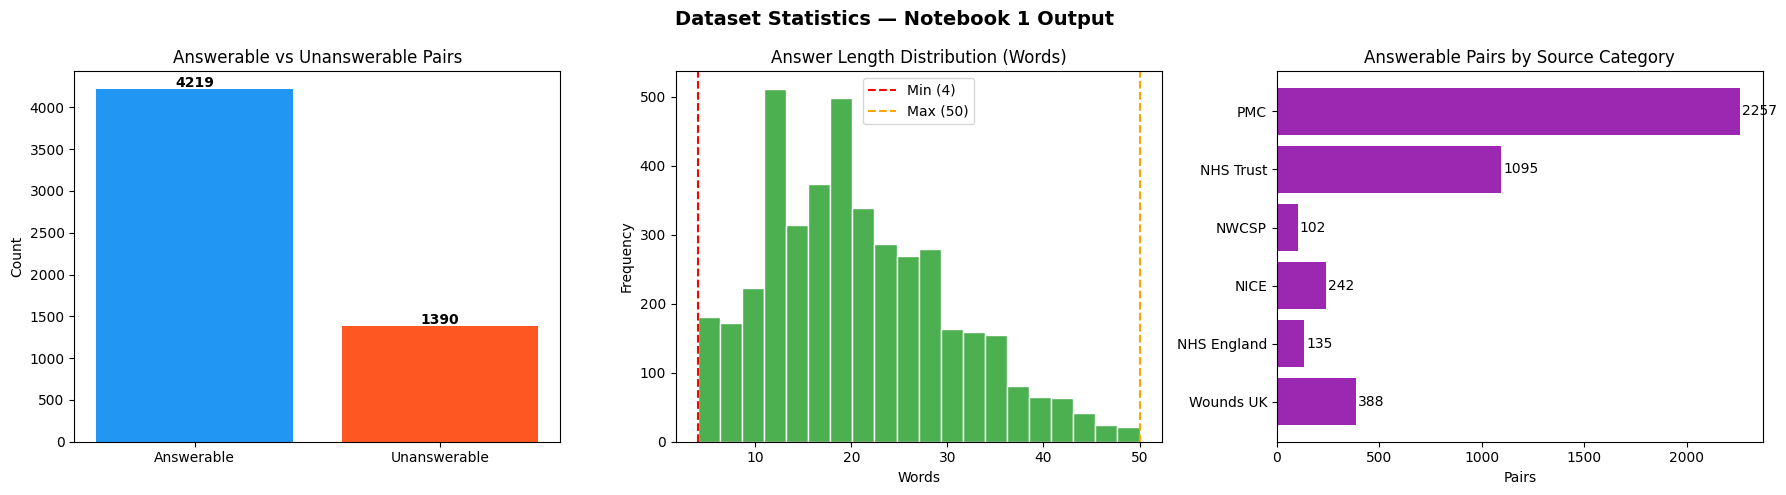

DATASET SUMMARY
  Total QA pairs       : 5609
  Answerable           : 4219  (75.2%)
  Unanswerable         : 1390  (24.8%)
  Unique sources       : 41
  Mean answer length   : 20.7 words
  Min answer length    : 4 words
  Max answer length    : 50 words

  Pairs by source category:
    PMC                  : 2,257
    NHS Trust            : 1,095
    Wounds UK            : 388
    NICE                 : 242
    NHS England          : 135
    NWCSP                : 102


In [22]:
with open(RAW_QA_PATH, "r", encoding="utf-8") as f:
    all_qa = json.load(f)

answerable   = [p for p in all_qa if not p["is_impossible"]]
unanswerable = [p for p in all_qa if p["is_impossible"]]

answer_lengths = [len(p["answer"].split()) for p in answerable]
source_counts  = Counter(p["source_key"] for p in answerable)

CATEGORY_LABELS = {
    "pmc":         "PMC",
    "nhs_trust":   "NHS Trust",
    "wounds_uk":   "Wounds UK",
    "nice":        "NICE",
    "nhs_england": "NHS England",
    "nwcsp":       "NWCSP",
}

category_counts = Counter()
for p in answerable:
    label = CATEGORY_LABELS.get(p["source_type"], p["source_type"])
    category_counts[label] += 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Dataset Statistics — Notebook 1 Output", fontsize=14, fontweight="bold")

axes[0].bar(["Answerable", "Unanswerable"], [len(answerable), len(unanswerable)],
            color=["#2196F3", "#FF5722"])
axes[0].set_title("Answerable vs Unanswerable Pairs")
axes[0].set_ylabel("Count")
for i, v in enumerate([len(answerable), len(unanswerable)]):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

axes[1].hist(answer_lengths, bins=20, color="#4CAF50", edgecolor="white")
axes[1].set_title("Answer Length Distribution (Words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
axes[1].axvline(x=MIN_ANSWER_WORDS, color="red", linestyle="--", label=f"Min ({MIN_ANSWER_WORDS})")
axes[1].axvline(x=MAX_ANSWER_WORDS, color="orange", linestyle="--", label=f"Max ({MAX_ANSWER_WORDS})")
axes[1].legend()

cat_labels = list(category_counts.keys())
cat_values = list(category_counts.values())
axes[2].barh(cat_labels, cat_values, color="#9C27B0")
axes[2].set_title("Answerable Pairs by Source Category")
axes[2].set_xlabel("Pairs")
axes[2].invert_yaxis()
for i, v in enumerate(cat_values):
    axes[2].text(v + 10, i, str(v), va="center")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "dataset_statistics.png"), dpi=150, bbox_inches="tight")
plt.show()

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"  Total QA pairs       : {len(all_qa)}")
print(f"  Answerable           : {len(answerable)}  ({len(answerable)/len(all_qa)*100:.1f}%)")
print(f"  Unanswerable         : {len(unanswerable)}  ({len(unanswerable)/len(all_qa)*100:.1f}%)")
print(f"  Unique sources       : {len(source_counts)}")
print(f"  Mean answer length   : {sum(answer_lengths)/len(answer_lengths):.1f} words")
print(f"  Min answer length    : {min(answer_lengths)} words")
print(f"  Max answer length    : {max(answer_lengths)} words")
print()
print("  Pairs by source category:")
for label, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"    {label:20} : {count:,}")
print("=" * 60)

### Dataset Statistics Output

The pipeline produced 5,609 QA pairs across 41 unique source documents. The answerable/unanswerable split is 75.2%/24.8%. The target unanswerable ratio was 33%; the shortfall to 24.8% reflects candidates discarded by the word-boundary regex where the answer span was found in the wrong-context chunk. This is the intended behaviour of the quality filter.
Answer lengths are normally distributed between the enforced bounds of 4 and 50 words, with a mean of 20.7 words, confirming that verbatim extraction produced substantive clinical spans rather than single-word fragments.
PMC is the largest contributor at 2,257 pairs, reflecting its 18-document share of the 41-document corpus. NHS Trust documents contributed 1,095 pairs. Wounds UK, NICE, NHS England, and NWCSP contributed the remaining 625 pairs across a clinically authoritative document set

## Notebook Summary

This notebook constructed a 5,609-pair extractive QA dataset from 41 clinical documents covering NHS pressure ulcer prevention and management guidance.

**Corpus Construction**

The final corpus comprises 23 primary source PDFs from NHS England, NICE, NWCSP, Wounds UK, and NHS Trust publications, supplemented by 18 PMC open-access papers retrieved via the NCBI E-Utilities API. Sources were selected for clinical authority and relevance to the NHS England governance framework.

**Text Extraction**

pdfplumber was trialled first but rejected. NHS and clinical guideline documents frequently use two-column layouts, and pdfplumber merged columns horizontally, producing incoherent text that would have corrupted the QA generation step. pymupdf4llm was adopted as it reconstructs reading order from the underlying PDF structure, preserving the logical flow of text across multi-column pages and retaining headings and bullet formatting.

**Text Cleaning**

A 13-pass cleaning pipeline was applied uniformly across all 41 documents: (1) extraction artefacts, (2) garbled PDF header lines, (3) table of contents removal, (4) unicode hygiene, (5) markdown link conversion, (6) citation and superscript removal, (7) URL and footer removal, (8) clinical synonym standardisation via TERM_MAP, (9) NHS acronym expansion, (10) Grade/Stage to Category normalisation, (11) measurement spacing, (12) bullet normalisation, and (13) admin section removal for NHS Trust documents. This ensured terminological consistency and removed structural noise before chunking.

**Chunking**

A token-based sliding window was used rather than word-based splitting because BERT operates on tokens, not words. A word-based approach produces chunks of inconsistent token length, making it impossible to guarantee that answer spans fit within the model's 512-token limit. The 384-token chunk size with 128-token overlap reserves capacity for the question and special tokens while preventing answer spans from splitting at boundaries. This produced 1,858 chunks across the 41 documents.

**QA Generation**

Gemini 2.5 Flash generated 4,219 answerable pairs from 1,858 chunks at 3 pairs per chunk. QA_PER_CHUNK was reduced from 15 to 3 after observing that higher quotas produced repetitive and paraphrased pairs with low validation retention. Unanswerable pairs were synthesised deterministically using wrong-context pairing rather than LLM generation, as an LLM cannot guarantee that a generated unanswerable is truly unanswerable in the clinical domain. 1,390 unanswerable pairs were produced against a 33% target; the shortfall to 24.8% reflects candidates discarded by the word-boundary regex quality filter.

During generation, the Gemini API returned intermittent 503 errors causing the pipeline to stop prematurely on repeated runs. Three measures were adopted to address this: a 0.5 second rate limit delay between requests to stay within Tier 1 quota, a 5-consecutive-error guard that halts the loop and prints a diagnostic message rather than silently failing, and a checkpoint saved every 50 chunks so that any interrupted run resumes from its last saved position rather than starting over.

**What Could Have Been Done Better**

The unanswerable ratio shortfall could have been avoided by running a small calibration sample first to measure the regex rejection rate, then adjusting `UNANSWERABLES_RATIO` upward accordingly to hit the 33% target. The QA validation filter checked only verbatim presence and word count; adding a clinical keyword check would have filtered out generic questions that pass validation but contribute little domain-specific training value. 243 chunks yielded zero pairs and were silently skipped; a targeted analysis of these chunks could have identified cleaning gaps or recovered additional pairs. PMC papers account for 53.5% of all pairs; capping contributions per source type would have produced a more balanced distribution across NHS policy and research literature, reducing the risk of training bias toward academic language. Finally, a vision-capable model such as Gemini could have been used to extract clinical content from flowcharts, diagrams, and image-based pages that pymupdf4llm cannot process, recovering information that was lost entirely during extraction.